In [2]:
# Step 1: Data Cleaning
# - Load df if needed
# - Basic checks (shape, dtypes, missing)
# - Remove duplicates
# - Remove zero / near-zero variance features
# - Remove highly correlated features

import numpy as np
import pandas as pd

if "df" not in globals():
    df = pd.read_csv("data.csv")

print(df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False).head(30))

start_cols = df.shape[1]
start_rows = df.shape[0]

# Drop duplicate rows
dup_count = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Separate target early (so we do not drop it accidentally)
target_col = "Class"
if target_col not in df.columns:
    raise ValueError("Target column Class not found in df columns")

feature_cols = [c for c in df.columns if c != target_col]

# Keep only numeric features for variance/correlation filtering
numeric_feature_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
non_numeric_feature_cols = [c for c in feature_cols if c not in numeric_feature_cols]

# Remove zero / near-zero variance (threshold = 0.01) on numeric features only
feat_vars = df[numeric_feature_cols].var(axis=0, ddof=0)
low_var_cols = feat_vars[feat_vars <= 0.01].index.tolist()
df = df.drop(columns=low_var_cols)

# Remove highly correlated features (abs corr > 0.95) among remaining numeric features
numeric_feature_cols_2 = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).columns.tolist()
corr_mat = df[numeric_feature_cols_2].corr().abs()

upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if (upper_tri[col] > 0.95).any()]
df = df.drop(columns=high_corr_cols)

end_cols = df.shape[1]
end_rows = df.shape[0]

removed_dups = dup_count
removed_low_var = len(low_var_cols)
removed_high_corr = len(high_corr_cols)
removed_total_features = (start_cols - end_cols)

print("Rows start:", start_rows)
print("Rows end:", end_rows)
print("Duplicate rows removed:", removed_dups)

print("Features start (incl target):", start_cols)
print("Low / zero variance numeric features removed:", removed_low_var)
print("Highly correlated numeric features removed:", removed_high_corr)
print("Total features removed (incl any overlap handled by drop):", removed_total_features)
print("Features end (incl target):", end_cols)

# Quick sanity check
print(df.head(3))

(171, 1204)
MATS3v             float64
nHBint10             int64
MATS3s             float64
MATS3p             float64
nHBDon_Lipinski      int64
                    ...   
nT5Ring              int64
SHdNH              float64
ETA_dEpsilon_C     float64
MDEO-22            float64
Class               object
Length: 1204, dtype: object
MATS3v            0
VAdjMat           0
MPC10             0
JGT               0
ATS2i             0
CrippenLogP       0
ATS2s             0
ATS2p             0
ATS2v             0
SHBint10          0
AATSC4i           0
AATSC4m           0
AATSC4c           0
AATSC4e           0
SHssNH            0
khs.dsN           0
maxHBa            0
ndNH              0
khs.ddssS         0
AATSC4s           0
nT7Ring           0
SHother           0
SpMin1_Bhv        0
nT11HeteroRing    0
SpMin1_Bhs        0
SpMin1_Bhp        0
SpMin1_Bhm        0
SpMin1_Bhi        0
ATSC6e            0
ATSC6c            0
dtype: int64
Rows start: 171
Rows end: 171
Duplicate rows remov

In [4]:
# Step 2: Preprocessing
# - Label encode target
# - Split into X, y
# - Standard scale numeric features

import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

target_col = "Class"
le = LabelEncoder()

# Explicit mapping expectation: NonToxic -> 0, Toxic -> 1
# LabelEncoder sorts alphabetically, so we enforce mapping manually to be safe
class_map = {"NonToxic": 0, "Toxic": 1}
if set(df[target_col].dropna().unique()) <= set(class_map.keys()):
    y = df[target_col].map(class_map).astype(int).values
else:
    y = le.fit_transform(df[target_col].values)
    print("LabelEncoder classes:", le.classes_)

X_df = df.drop(columns=[target_col]).copy()

# Keep numeric columns (your descriptors should be numeric; this avoids surprises)
X_df = X_df.select_dtypes(include=[np.number]).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)

print(X_scaled.shape)
unique_vals, counts_vals = np.unique(y, return_counts=True)
print(pd.Series(counts_vals, index=unique_vals))

(171, 560)
0    115
1     56
dtype: int64


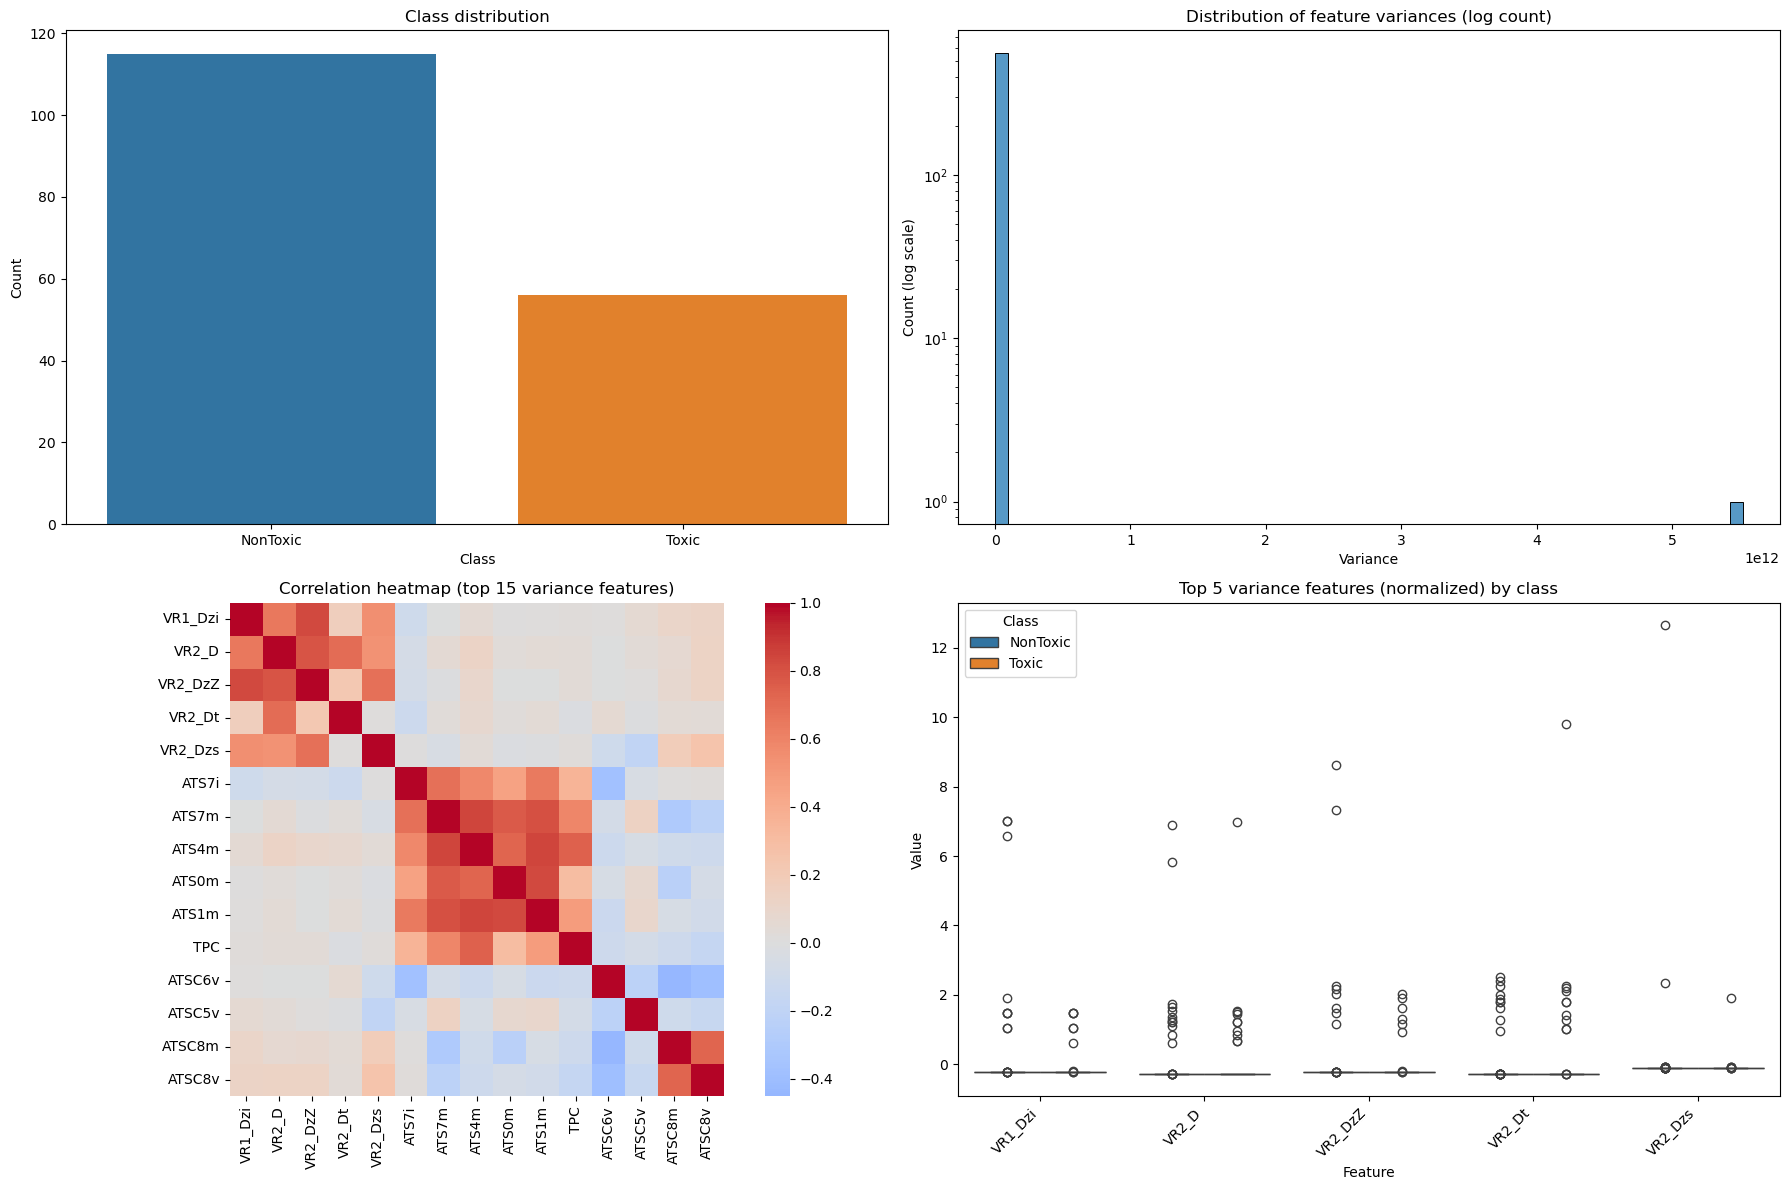

In [12]:
# Step 3: EDA
# - 2x2 subplot figure:
#   1) class distribution
#   2) feature variance histogram (log y)
#   3) correlation heatmap of top-15 variance features
#   4) boxplots (Toxic vs NonToxic) for top-5 variance features (normalized)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "Class"

# Rebuild X_df and y from current df
class_map = {"NonToxic": 0, "Toxic": 1}
y_series = df[target_col].map(class_map).astype(int)

X_df = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()

feat_vars = X_df.var(axis=0, ddof=0).sort_values(ascending=False)
top15 = feat_vars.head(15).index.tolist()
top5 = feat_vars.head(5).index.tolist()

# Normalized copy for boxplots
X_norm = (X_df - X_df.mean(axis=0)) / (X_df.std(axis=0, ddof=0).replace(0, 1))
plot_box_df = X_norm[top5].copy()
plot_box_df["Class"] = y_series.map({0: "NonToxic", 1: "Toxic"})

plt.figure(figsize=(18, 12))

# 1) Class distribution
plt.subplot(2, 2, 1)
class_counts = df[target_col].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, legend=False)
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")

# 2) Variance distribution
plt.subplot(2, 2, 2)
sns.histplot(feat_vars.values, bins=60)
plt.yscale("log")
plt.title("Distribution of feature variances (log count)")
plt.xlabel("Variance")
plt.ylabel("Count (log scale)")

# 3) Correlation heatmap of top-15 variance features
plt.subplot(2, 2, 3)
corr_top15 = X_df[top15].corr()
sns.heatmap(corr_top15, cmap="coolwarm", center=0, square=True, cbar=True)
plt.title("Correlation heatmap (top 15 variance features)")

# 4) Boxplots for top-5 variance features by class
plt.subplot(2, 2, 4)
melt_df = plot_box_df.melt(id_vars="Class", value_vars=top5, var_name="Feature", value_name="Value")
sns.boxplot(data=melt_df, x="Feature", y="Value", hue="Class")
plt.title("Top 5 variance features (normalized) by class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
# Step 4: Feature Selection
# - ANOVA F-test top 30
# - Mutual Information top 30
# - Random Forest importances top 30
# - Extra Trees importances top 30
# - Consensus: appears in at least 2 methods
# - Final: top 20 (within consensus) by Random Forest importance
# Produces:
# - selected_features (list)
# - X_selected_df (DataFrame for modeling)

import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

target_col = "Class"
class_map = {"NonToxic": 0, "Toxic": 1}
y = df[target_col].map(class_map).astype(int).values

X_df = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
feature_names = X_df.columns.tolist()
X_vals = X_df.values

k_top = 30

# ANOVA
anova_selector = SelectKBest(score_func=f_classif, k=min(k_top, X_df.shape[1]))
anova_selector.fit(X_vals, y)
anova_idx = np.argsort(anova_selector.scores_)[::-1]
anova_top = [feature_names[i] for i in anova_idx[:min(k_top, len(anova_idx))]]

# Mutual information
mi_selector = SelectKBest(score_func=mutual_info_classif, k=min(k_top, X_df.shape[1]))
mi_selector.fit(X_vals, y)
mi_idx = np.argsort(mi_selector.scores_)[::-1]
mi_top = [feature_names[i] for i in mi_idx[:min(k_top, len(mi_idx))]]

# Random Forest importances
rf_fs = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight="balanced")
rf_fs.fit(X_vals, y)
rf_imp = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)
rf_top = rf_imp.head(min(k_top, rf_imp.shape[0])).index.tolist()

# Extra Trees importances
et_fs = ExtraTreesClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight="balanced")
et_fs.fit(X_vals, y)
et_imp = pd.Series(et_fs.feature_importances_, index=feature_names).sort_values(ascending=False)
et_top = et_imp.head(min(k_top, et_imp.shape[0])).index.tolist()

# Consensus (>= 2 methods)
all_lists = [anova_top, mi_top, rf_top, et_top]
feat_votes = pd.Series(0, index=feature_names, dtype=int)
for lst in all_lists:
    feat_votes.loc[lst] = feat_votes.loc[lst] + 1

consensus = feat_votes[feat_votes >= 2].sort_values(ascending=False).index.tolist()

# Final top 20 by RF importance, restricted to consensus
rf_consensus_sorted = rf_imp.loc[rf_imp.index.intersection(consensus)].sort_values(ascending=False)
selected_features = rf_consensus_sorted.head(min(20, rf_consensus_sorted.shape[0])).index.tolist()

print("ANOVA top 30:")
print(anova_top)
print("MI top 30:")
print(mi_top)
print("RF top 30:")
print(rf_top)
print("ExtraTrees top 30:")
print(et_top)

print("Consensus features (>=2 methods):")
print(consensus)

print("Final selected features (top 20 by RF within consensus):")
print(selected_features)

X_selected_df = X_df[selected_features].copy()
print(X_selected_df.shape)

ANOVA top 30:
['EE_Dt', 'C2SP2', 'MLogP', 'nAcid', 'nwHBa', 'ATSC1v', 'AATS8m', 'AATS8v', 'nHBint6', 'SpMAD_Dt', 'MDEC-23', 'SpMax4_Bhm', 'ATSC7p', 'SpMin3_Bhe', 'ZMIC1', 'nBondsD', 'SpAD_Dt', 'minHBint4', 'ETA_Eta_F_L', 'nC', 'C3SP2', 'VR3_Dt', 'ECCEN', 'VR2_Dt', 'MATS8c', 'GATS1i', 'AATS1i', 'minssNH', 'SP-6', 'naAromAtom']
MI top 30:
['nHBint2', 'ATSC8i', 'ETA_Alpha', 'MDEC-23', 'AATSC2s', 'Kier2', 'VR1_Dzi', 'minHBint3', 'MATS8i', 'MATS6c', 'SsssN', 'C1SP3', 'GATS2e', 'nA', 'CIC2', 'GGI3', 'ATS4p', 'GATS3s', 'GATS5v', 'ATSC6c', 'SsCH3', 'MDEC-14', 'minaaN', 'ZMIC2', 'nBondsD2', 'SssssC', 'SHaaCH', 'AATSC8i', 'GGI4', 'C1SP2']
RF top 30:
['ZMIC1', 'MDEC-23', 'SpMax7_Bhe', 'SHaaCH', 'ATSC8i', 'SpAD_Dt', 'SpMAD_Dt', 'CIC2', 'SpMin3_Bhe', 'AATSC8i', 'EE_Dt', 'CIC1', 'ETA_Eta_F_L', 'ZMIC2', 'MATS8i', 'piPC3', 'SP-6', 'ATSC7p', 'GATS3e', 'AATSC3v', 'SpMax8_Bhi', 'SpMax3_Bhv', 'ATSC1v', 'MDEC-22', 'LipoaffinityIndex', 'SCH-7', 'ATSC5i', 'ATSC3p', 'MIC1', 'ATS7p']
ExtraTrees top 30:
['C1SP2

                    accuracy_mean  accuracy_std  roc_auc_mean  roc_auc_std  \
Model                                                                        
RandomForest             0.660840      0.043664      0.679051     0.032752   
SVM_RBF                  0.620000      0.015158      0.665152     0.047264   
GradientBoosting         0.643193      0.034878      0.635112     0.064988   
LogisticRegression       0.591092      0.047923      0.628656     0.061055   

                     f1_mean    f1_std  precision_mean  precision_std  \
Model                                                                   
RandomForest        0.277535  0.137970        0.466667       0.171594   
SVM_RBF             0.542905  0.039579        0.447527       0.013287   
GradientBoosting    0.358349  0.158396        0.407143       0.114286   
LogisticRegression  0.478813  0.092137        0.407878       0.055581   

                    recall_mean  recall_std  
Model                                        


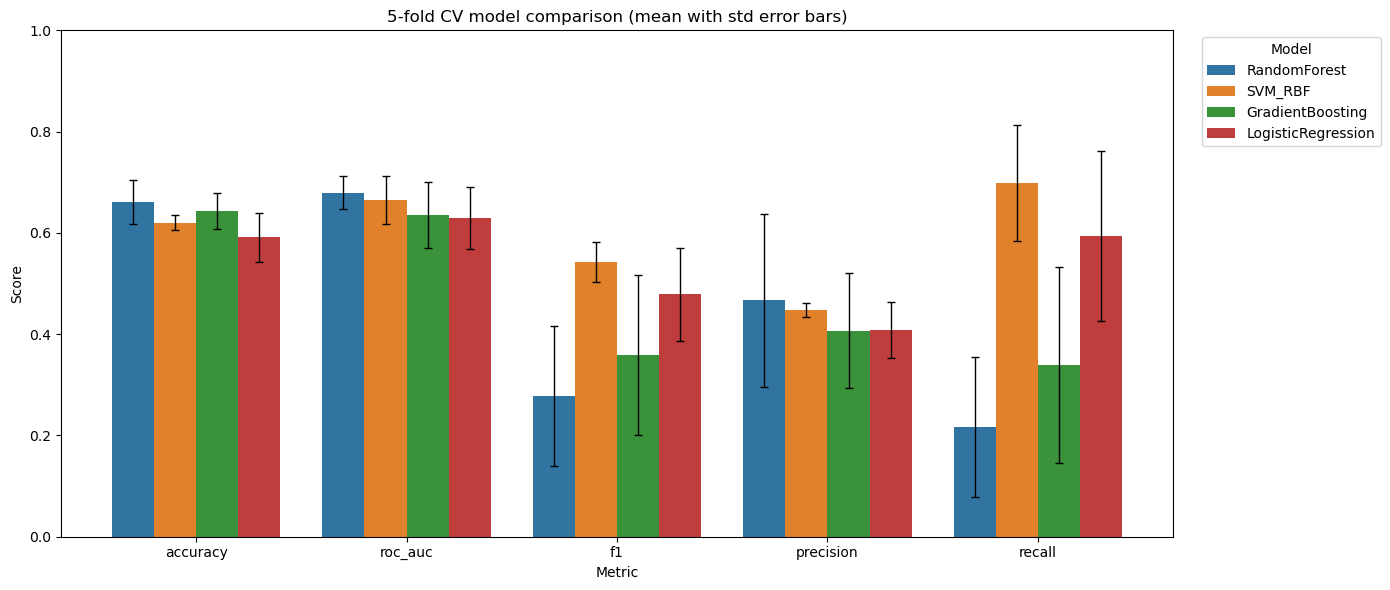

RandomForest


In [9]:
# Step 5: Model comparison with stratified 5-fold CV
# - Uses Pipeline where scaling is needed
# - Reports mean ± std for Accuracy, AUC, F1, Precision, Recall
# - Table + grouped bar plot with error bars

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Build X, y from selected features
target_col = "Class"
class_map = {"NonToxic": 0, "Toxic": 1}
y = df[target_col].map(class_map).astype(int).values

X_model_df = X_selected_df.copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

models = {
    "RandomForest": RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced"))
    ]),
    "SVM_RBF": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42, class_weight="balanced"))
    ])
}

rows = []
for model_name, model_obj in models.items():
    cv_out = cross_validate(
        model_obj,
        X_model_df.values,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    row = {"Model": model_name}
    for metric_name in scoring.keys():
        vals = cv_out["test_" + metric_name]
        row[metric_name + "_mean"] = float(np.mean(vals))
        row[metric_name + "_std"] = float(np.std(vals, ddof=0))
    rows.append(row)

results_df = pd.DataFrame(rows).set_index("Model").sort_values("roc_auc_mean", ascending=False)
print(results_df)

# Plot grouped bars with error bars for means/stds
plot_metrics = ["accuracy", "roc_auc", "f1", "precision", "recall"]
plot_df = []
for model_name in results_df.index:
    for metric_name in plot_metrics:
        plot_df.append({
            "Model": model_name,
            "Metric": metric_name,
            "Mean": results_df.loc[model_name, metric_name + "_mean"],
            "Std": results_df.loc[model_name, metric_name + "_std"]
        })
plot_df = pd.DataFrame(plot_df)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="Metric", y="Mean", hue="Model", capsize=0.0)

# Add error bars manually
metric_order = plot_metrics
model_order = results_df.index.tolist()
x_positions = {m: i for i, m in enumerate(metric_order)}

bar_i = 0
for metric_name in metric_order:
    for model_name in model_order:
        sub = plot_df[(plot_df["Metric"] == metric_name) & (plot_df["Model"] == model_name)].iloc[0]
        x_center = x_positions[metric_name]
        n_models = len(model_order)
        group_width = 0.8
        bar_width = group_width / n_models
        x_offset = (-group_width / 2) + (bar_width / 2) + (bar_i % n_models) * bar_width
        plt.errorbar(
            x=x_center + x_offset,
            y=sub["Mean"],
            yerr=sub["Std"],
            fmt="none",
            ecolor="black",
            elinewidth=1,
            capsize=3
        )
        bar_i += 1

plt.ylim(0, 1.0)
plt.title("5-fold CV model comparison (mean with std error bars)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(best_model_name)

Best model: RandomForest

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.71      0.86      0.78       115
       Toxic       0.48      0.27      0.34        56

    accuracy                           0.67       171
   macro avg       0.60      0.56      0.56       171
weighted avg       0.63      0.67      0.64       171



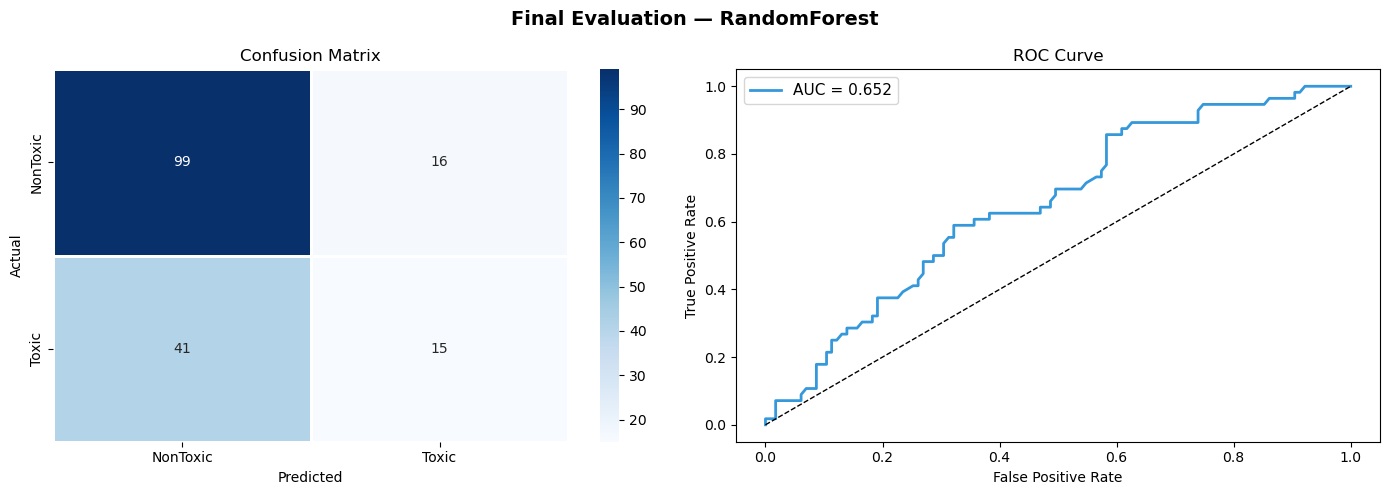

In [20]:
# Step 6: Final prediction & evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

target_col = "Class"
class_map = {"NonToxic": 0, "Toxic": 1}
y = df[target_col].map(class_map).astype(int).values
X_model_df = X_selected_df.copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "RandomForest":      RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1),
    "GradientBoosting":  GradientBoostingClassifier(n_estimators=200, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM":               SVC(kernel="rbf", probability=True, random_state=42),
}

# Pick best model by AUC from Step 5 results
# (assumes cv_results dict exists from Step 5, otherwise defaults to RandomForest)
try:
    best_name = max(cv_results, key=lambda m: cv_results[m]["AUC-ROC"])
except:
    best_name = "RandomForest"

print(f"Best model: {best_name}")
best_model = models[best_name]

# Out-of-fold predictions
y_pred  = cross_val_predict(best_model, X_model_df, y, cv=cv, method="predict")
y_proba = cross_val_predict(best_model, X_model_df, y, cv=cv, method="predict_proba")[:, 1]

# Classification report
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=["NonToxic", "Toxic"]))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Final Evaluation — {best_name}", fontsize=14, fontweight="bold")

# Confusion matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["NonToxic", "Toxic"],
            yticklabels=["NonToxic", "Toxic"],
            linewidths=1, linecolor="white")
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(y, y_proba)
auc_score = roc_auc_score(y, y_proba)
axes[1].plot(fpr, tpr, color="#3498DB", linewidth=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()